# AG-HYPOPT · Trial 03

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_03. Registry has two trials:

- trial_01 = target rule, h_f 5.349, h_s 7.652 -> objective 0.0837 ± 0.0211 (gamma finite, 0 diverged).
- trial_02 = sim rule, h_f 5.308, h_s 3.060 -> objective 0.1249 ± 0.0398 (gamma finite, 0 diverged).

Current best is trial_01 (0.0837). The two trials used nearly the same bandwidth scale (~5.3), so they
compare the RULES at fixed scale: target 0.0837 vs sim 0.1249, with the sim loss coming from a gamma
collapse in the four low-count cells (gamma to 31-40 % of truth). The reference for "good" remains
exp6's target, h_f 4.0, h_s 3.675 -> 0.0803. The third rule, `power`, has not been tested at all.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_03'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (2/5 trials)
ID |     ei | params
 1 |      - | {"bandwidth_rule": "power", "h_f_scale": 3.604915572557097, "h_s_scale": 9.814019117270366}
 2 |      - | {"bandwidth_rule": "target", "h_f_scale": 7.403782396708046, "h_s_scale": 2.035415064644391}
 3 |      - | {"bandwidth_rule": "target", "h_f_scale": 6.269564279549174, "h_s_scale": 2.7571280610078643}
 4 |      - | {"bandwidth_rule": "sim", "h_f_scale": 9.08034866550136, "h_s_scale": 2.2503922191354375}
 5 |      - | {"bandwidth_rule": "sim", "h_f_scale": 6.684142008835001, "h_s_scale": 5.736908224555956}
 6 |      - | {"bandwidth_rule": "sim", "h_f_scale": 7.454784285819548, "h_s_scale": 9.116215660213761}
 7 |      - | {"bandwidth_rule": "power", "h_f_scale": 4.126212801236706, "h_s_scale": 8.134019277878075}
 8 |      - | {"bandwidth_rule": "power", "h_f_scale": 8.65837596337171, "h_s_scale": 4.219928239137358}
 9 |      - | {"bandwidth_rule": "power", "h_f_scale": 11.70806302243054, "h_s_scale": 4.282413453185632}

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Two trials done, both at bandwidth scale ~5.3, which already isolates the rule: target = 0.0837, sim =
0.1249. The remaining gap in the design is the third rule, `power`, which is completely untested; without
it the campaign cannot answer its own question ("does the rule matter, and which one wins?"). So the
next trial should switch on `power`.

The `power` candidates are #1 (3.60/9.81), #7 (4.13/8.13), #8 (8.66/4.22) and #9 (11.71/4.28). For a
meaningful rule comparison the bandwidth should stay in the moderate range where target and sim were
tested and where exp6's optimum sits (h_f around 4-5, h_s a few units), rather than near the cap where
a flat kernel can kill the mu channel. Candidate #8 (h_f 8.66, h_s 4.22) is the most central power
option: its h_s is close to exp6's winning 3.675 and its h_f is in the same broad region as the two
trials so far. #1/#7 push h_s to 8-10 (unexplored and likely too flat on the sigma channel), #9 sits
near the h_f cap.

I choose candidate 8 (power, h_f_scale 8.658, h_s_scale 4.220).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 8            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'power', 'h_f_scale': 8.65837596337171, 'h_s_scale': 4.219928239137358}
Running  1nW Trans05 ... 

μ 9.39 -> 18.70 | γ 8.5 -> 7.71 | NLL 2.92


Running  1nW Trans20 ... 

μ 17.32 -> 19.73 | γ 8.5 -> 4.50 | NLL 0.11


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 60.84 | γ 14.1 -> 13.12 | NLL 0.34


Running 3nW Trans100 ... 

μ 175.71 -> 94.43 | γ 14.1 -> 12.93 | NLL 0.17



Total: 7.3 min


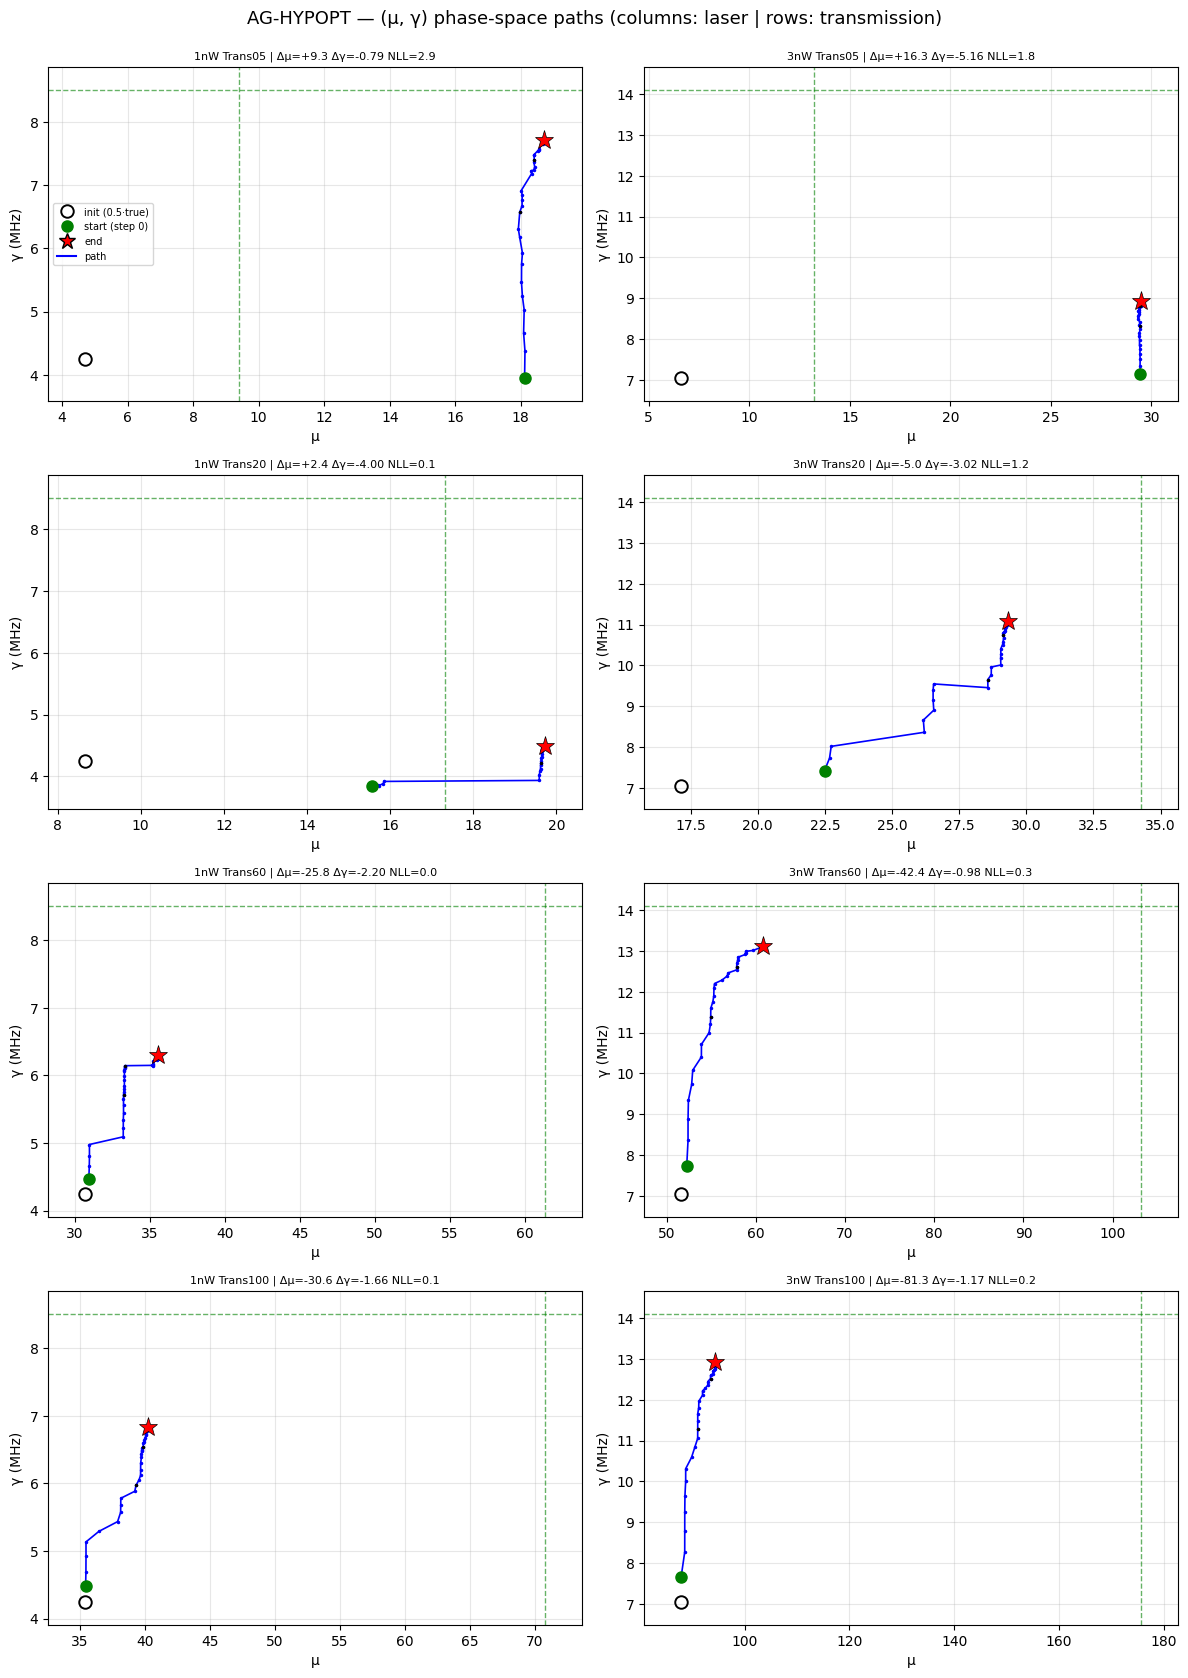

trial finished in 7.3 min
objective = 0.1541 ± 0.0791
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39   18.70   +99.1 |     8.50    7.71    -9.3
1nW Trans20       17.32   19.73   +13.9 |     8.50    4.50   -47.1
1nW Trans60       61.37   35.57   -42.0 |     8.50    6.30   -25.8
1nW Trans100       70.82   40.23   -43.2 |     8.50    6.84   -19.6
3nW Trans05       13.20   29.50  +123.4 |    14.10    8.94   -36.6
3nW Trans20       34.28   29.33   -14.4 |    14.10   11.08   -21.4
3nW Trans60      103.20   60.84   -41.0 |    14.10   13.12    -6.9
3nW Trans100      175.71   94.43   -46.3 |    14.10   12.93    -8.3

weighted objective (T-graded, cap=1.0) = 0.1541 | diverged cells: 0
μ: RMSE 36.029 (rel 64.1%, bias -19.620) | γ: RMSE 2.790 (rel 25.7%, bias -2.372)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

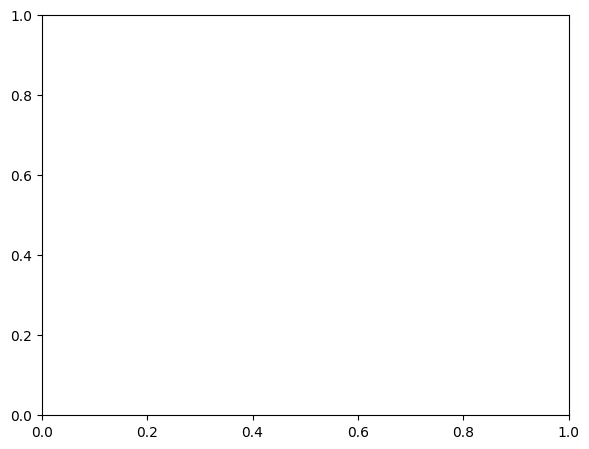

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.1541 ± 0.0791, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
power, h_f_scale = 8.658, h_s_scale = 4.220.

This is the worst of the three trials so far and it fails differently from trial_02. mu rel-RMSE is the
dominant error (mu bias is erratic rather than uniformly negative): mu overshoots badly on the low-count
cells (1nW Trans05 18.70 vs 9.39, +99.1 %; 3nW Trans05 29.50 vs 13.20, +123.4 %; 1nW Trans20 +13.9 %)
while staying underestimated at high T (3nW Trans100 -46.3 %, 1nW Trans100 -43.2 %). gamma is
underestimated throughout (-6.9 % to -47.1 %). The objective 0.1541 is roughly double trial_01's 0.0837.

Trial ranking at matched bandwidth scale (~5.3, exp6-scale ~4): target (trial_01) 0.0837 < sim
(trial_02) 0.1249 < power (trial_03) 0.1541. So the RULE matters a lot, and so far `target` (the exp5/exp6
design) is clearly the best, with the two alternatives each failing through a different channel: sim
collapses gamma on low-count cells, power blows mu up on them. Both failures are concentrated in the
Trans05/Trans20 cells, which is where the model is known to be weakest (FM#8).

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed
before it, so the trial stands. No rerun.

**Summary:** Trial 3 (power rule, h_f 8.658, h_s 4.220) scores objective 0.1541 ± 0.0791 with gamma finite and no divergence, the worst so far, driven by a mu overshoot of up to +123 % on the low-count cells.
**Key insight:** The `power` rule is the worst of the three; with {target, sim, power} at comparable scale giving {0.0837, 0.1249, 0.1541}, the bandwidth RULE is a first-order lever and `target` is the clear front-runner.

Notes for Anuar (optional, not acted on): the two alternative rules fail through the low-count cells but
in opposite ways (sim collapses gamma, power explodes mu), which is itself a useful signal about where
the sigma-channel likelihood is misfit.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 3 (power rule, h_f 8.658, h_s 4.220) scores objective 0.1541 ± 0.0791 with gamma finite and no divergence, the worst so far, driven by a mu overshoot of up to +123 % on the low-count cells."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "The `power` rule is the worst of the three; with {target, sim, power} at comparable scale giving {0.0837, 0.1249, 0.1541}, the bandwidth RULE is a first-order lever and `target` is the clear front-runner."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_03 | current best: trial_01


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_04.ipynb. Open it and follow its cells from the top.
